# Défi quotidien : évaluer de grands modèles linguistiques


👩‍🏫 👩🏿‍🏫 Ce que vous apprendrez
L’importance d’évaluer les LLM en termes de performances, de fiabilité et de sécurité.
Les défis liés à l’évaluation du LLM.
Un aperçu des différentes méthodes d’évaluation, y compris les mesures de chevauchement de contenu, les mesures basées sur des modèles, l’évaluation humaine et les tests contradictoires.
Compréhension approfondie des métriques BLEU, ROUGE et Perplexity.
Réflexion critique dans le choix de la bonne mesure d’évaluation pour différentes applications.


🛠️ Ce que vous allez créer
Vous réaliserez des exercices pour appliquer les scores BLEU et ROUGE à un échantillon de texte, analyser les scores de perplexité, effectuer des tests contradictoires et proposer des améliorations aux méthodologies d'évaluation LLM.



Tâche
1. Comprendre l’évaluation du LLM :

Expliquez pourquoi l’évaluation des LLM est plus complexe que celle des logiciels traditionnels.
Identifier les principales raisons pour lesquelles il faut évaluer la sécurité d’un LLM.
Décrivez comment les tests contradictoires contribuent à l’amélioration du LLM.
Discutez des limites des mesures d’évaluation automatisées et de la façon dont elles se comparent à l’évaluation humaine.


2. Application des métriques BLEU et ROUGE :

Calculez le score BLEU pour l'exemple suivant :

Référence : « Malgré le recours croissant à l’intelligence artificielle dans divers secteurs, la surveillance humaine reste essentielle pour garantir une mise en œuvre éthique et efficace. »
Généré : « Bien que l’IA soit de plus en plus utilisée dans les industries, la supervision humaine reste nécessaire pour une application éthique et efficace. »
Calculez le score ROUGE pour l'exemple suivant :

Référence : « Face au changement climatique rapide, les initiatives mondiales doivent se concentrer sur la réduction des émissions de carbone et le développement de sources d’énergie durables pour atténuer l’impact environnemental. »
Généré : « Pour lutter contre le changement climatique, les efforts mondiaux devraient viser à réduire les émissions de carbone et à renforcer le développement des énergies renouvelables. »
Fournir une analyse des limites de BLEU et ROUGE lors de l’évaluation de textes créatifs ou contextuels.

Proposez des améliorations ou des méthodes alternatives pour évaluer la génération de texte.



3. Analyse de la perplexité :

Comparez la perplexité des deux modèles de langage en fonction de la probabilité attribuée à un mot :

Modèle A : Attribue une probabilité de 0,8 à « l’atténuation ».
Modèle B : Attribue une probabilité de 0,4 à « l’atténuation ».
Déterminez quel modèle présente le moins de perplexité et expliquez pourquoi.

Étant donné un modèle de langage dont le score de perplexité est de 100, discutez de ses implications en termes de performances et des moyens possibles de l’améliorer.



4. Exercice d’évaluation humaine :

Évaluez la fluidité de la réponse de ce chatbot à l'aide d'une échelle de Likert (1 à 5) : « Toutes mes excuses, mais je ne comprends pas. Pourriez-vous reformuler votre question ? »
Justifiez votre note.
Proposez une version améliorée de la réponse et expliquez pourquoi elle est meilleure.


5. Exercice de test contradictoire :

Identifiez l’erreur potentielle qu’un LLM pourrait commettre en répondant à la question : « Quelle est la capitale de la France ? »

Attendu : « Paris. »
Proposez une méthode pour améliorer la robustesse contre de telles erreurs.

Créez au moins trois questions délicates qui pourraient remettre en question la robustesse, la détection des biais ou l’exactitude factuelle d’un LLM.



6. Analyse comparative des méthodes d’évaluation :

Choisissez une tâche PNL (par exemple, traduction automatique, résumé de texte, réponse à des questions).
Comparez et opposez au moins trois mesures d’évaluation différentes (BLEU, ROUGE, BERTScore, Perplexité, Évaluation humaine, etc.).
Discutez de la mesure la plus appropriée pour la tâche choisie et pourquoi.

# 1. Compréhension théorique

 - Les LLM sont plus complexes à évaluer car ils produisent des sorties ouvertes (open-ended), 
   avec une infinité de réponses valides selon le contexte, contrairement aux logiciels traditionnels.
 - Il faut évaluer la sécurité pour détecter la toxicité, biais, hallucinations et abus potentiels.
 - Les tests contradictoires testent la robustesse en exposant le modèle à des inputs difficiles.
 - Les mesures automatiques sont rapides mais peu fiables sur la qualité sémantique ou la créativité, contrairement aux évaluations humaines plus coûteuses mais pertinentes.


## 2. BLEU et ROUGE

In [7]:
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer

### BLEU
reference_bleu = ["Malgré le recours croissant à l’intelligence artificielle dans divers secteurs, la surveillance humaine reste essentielle pour garantir une mise en œuvre éthique et efficace.".split()]
generated_bleu = "Bien que l’IA soit de plus en plus utilisée dans les industries, la supervision humaine reste nécessaire pour une application éthique et efficace.".split()

bleu_score = sentence_bleu(reference_bleu, generated_bleu)
print(f"Score BLEU : {bleu_score:.4f}")

### ROUGE
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
reference_rouge = "Face au changement climatique rapide, les initiatives mondiales doivent se concentrer sur la réduction des émissions de carbone et le développement de sources d’énergie durables pour atténuer l’impact environnemental."
generated_rouge = "Pour lutter contre le changement climatique, les efforts mondiaux devraient viser à réduire les émissions de carbone et à renforcer le développement des énergies renouvelables."
rouge_scores = scorer.score(reference_rouge, generated_rouge)
print(f"Scores ROUGE : {rouge_scores}")

# Limites BLEU/ROUGE : ils ignorent la sémantique et pénalisent la paraphrase correcte. Peu fiables pour textes créatifs.
# Alternatives : BERTScore (prise en compte de la sémantique), évaluation humaine, tests contradictoires.

Score BLEU : 0.0000
Scores ROUGE : {'rouge1': Score(precision=0.56, recall=0.4117647058823529, fmeasure=0.4745762711864407), 'rouge2': Score(precision=0.25, recall=0.18181818181818182, fmeasure=0.2105263157894737), 'rougeL': Score(precision=0.48, recall=0.35294117647058826, fmeasure=0.4067796610169491)}


Analyse rapide :

* **Score BLEU = 0.0000** :
  Très mauvais score, indique qu'aucune correspondance exacte de n-grammes n’a été trouvée (probablement à cause d’une reformulation forte ou synonymes). Cela montre que BLEU est trop strict, surtout sur des textes paraphrasés.

* **ROUGE-1 (f1 ≈ 47%)** :
  Bon rappel et précision moyens sur les mots uniques. Ça montre une certaine similarité lexicale mais pas parfaite.

* **ROUGE-2 (f1 ≈ 21%)** :
  Score faible sur les bigrammes (groupes de 2 mots), donc peu de similarité sur la structure de phrases.

* **ROUGE-L (f1 ≈ 41%)** :
  Indique une certaine correspondance sur les séquences longues (longest common subsequence), meilleure qu’un hasard mais pas excellente.

### Conclusion :

BLEU échoue totalement car trop sensible aux reformulations ; ROUGE capte mieux la similarité mais reste limité. Le texte généré est *paraphrasé* correctement mais *très différent lexicalement*. Résultat classique pour textes paraphrasés ou résumés.


## 3. Analyse Perplexité

In [8]:
import math

# Perplexité = 1 / P(mot) donc modèle A a perplexité 1/0.8 = 1.25, modèle B = 1/0.4 = 2.5
perplexity_A = 1 / 0.8
perplexity_B = 1 / 0.4
print(f"Perplexité Modèle A : {perplexity_A:.2f}")
print(f"Perplexité Modèle B : {perplexity_B:.2f}")

# Modèle A est meilleur car perplexité plus faible = prédictions plus confiantes.

# Perplexité = 100 implique mauvaise prédiction, probablement sur données hors distribution.
# Pour l'améliorer : affiner le modèle, ajouter données pertinentes, ajuster hyperparamètres.

Perplexité Modèle A : 1.25
Perplexité Modèle B : 2.50


Analyse :

* **Modèle A (perplexité 1.25)** prédit le mot avec beaucoup plus de confiance (proba 0.8), il est donc **meilleur** et plus sûr sur cette prédiction.

* **Modèle B (perplexité 2.5)** est deux fois plus incertain (proba 0.4), ce qui indique un modèle **moins performant** pour ce mot précis.

### Conclusion :

**Perplexité plus basse = meilleur modèle** pour la prédiction de ce mot. Modèle A est **plus sûr et performant** ici.


## 4. Évaluation humaine

In [9]:
# 4. Évaluation humaine
# Note Likert de 1 (très mauvais) à 5 (très bon)
# Exemple : "Toutes mes excuses, mais je ne comprends pas. Pourriez-vous reformuler votre question ?"
likert_note = 4
print(f"Note Likert : {likert_note}")
# Justification : réponse polie, claire, mais peut être améliorée en étant plus engageante.

# Version améliorée : "Je suis désolé, je n'ai pas bien compris. Pouvez-vous préciser ou reformuler votre question s'il vous plaît ?"
# Amélioration : langage plus humain, engage l'utilisateur à clarifier.

Note Likert : 4


### Analyse :

* **Note 4/5** = bonne fluidité générale.
* Points positifs : phrase claire, polie, compréhensible.
* Point d’amélioration : manque un ton plus naturel ou empathique pour atteindre 5/5 (un peu robotique).

### Conclusion :

Réponse correcte mais améliorable avec un style plus humain ou engageant (ex : « Bien sûr, pouvez-vous préciser votre demande ? »).


## 5. Test contradictoire

In [ ]:
# Erreur possible : hallucination, exemple "Lyon" ou "Marseille" au lieu de "Paris".
# Solution : cross-validation avec bases de connaissances fiables, filtres de factualité.

# Trois questions pièges :
questions_difficiles = [
    "Quel est le président actuel de la France en 2050 ?", # Futur
    "Combien de pattes a un dragon ?", # Entité fictive
    "Quelle est la capitale de l'Atlantide ?" # Mythe
]
print(f"Questions difficiles : {questions_difficiles}")

Questions difficiles : ['Quel est le président actuel de la France en 2050 ?', 'Combien de pattes a un dragon ?', "Quelle est la capitale de l'Atlantide ?"]


### Analyse :

* **Question 1** : piège temporel → un bon LLM doit reconnaître l’absence d’information sur le futur.
* **Question 2** : entité fictive → vérifier la capacité à reconnaître un être imaginaire sans inventer une réponse crédible.
* **Question 3** : mythe / lieu inexistant → test de gestion des faits mythologiques et de détection de l’inexistence.

### Conclusion :

Ces questions testent :

* **robustesse factuelle**,
* **détection de fiction**,
* **gestion du contexte temporel**.
  Elles visent à détecter hallucinations et excès de confiance du modèle.


## 6. Analyse comparative

In [10]:
# Exemple : Résumé de texte
# BLEU : utile mais trop strict sur le mot à mot.
# ROUGE : mesure la couverture, mieux pour résumé.
# BERTScore : encode le sens, mieux sur paraphrase.
# Perplexité : peu utile car ne corrèle pas avec la qualité perçue.
# Évaluation humaine : indispensable pour sens global et fluidité.

# Conclusion : pour résumé, ROUGE et BERTScore sont les plus pertinents, avec un complément humain.

print("\nConclusion : combinaison ROUGE + BERTScore + évaluation humaine recommandée pour les résumés.")


Conclusion : combinaison ROUGE + BERTScore + évaluation humaine recommandée pour les résumés.


### Analyse directe :

* **ROUGE** : mesure la couverture lexicale → utile pour vérifier si les informations clés sont présentes.
* **BERTScore** : intègre la similarité sémantique → capte mieux la reformulation et la paraphrase.
* **Évaluation humaine** : essentielle pour juger la qualité perçue (fluidité, pertinence, logique).

### Conclusion finale :

Cette combinaison est équilibrée : **quantitatif (ROUGE + BERTScore)** + **qualitatif (humain)**, idéale pour évaluer des résumés, surtout sur des textes ouverts et variés.


## 7. Bilan

### Bilan rapide de l’exercice

Cet exercice couvre les points essentiels de l’évaluation des LLM :

* **Évaluation théorique** : importance d’évaluer non seulement la performance mais aussi la sécurité et la fiabilité des LLM, avec des limites des mesures automatiques sur des tâches complexes.

* **Métriques automatiques** :

  * **BLEU** trop strict, peu adapté aux paraphrases.
  * **ROUGE** pertinent pour la couverture d’informations mais limité sur la sémantique.
  * **BERTScore** et **évaluation humaine** mieux adaptés aux contextes créatifs.

* **Perplexité** : mesure utile pour la prédiction brute mais insuffisante pour évaluer la qualité finale perçue par l’utilisateur.

* **Évaluation humaine** : indispensable pour juger la fluidité et la pertinence.

* **Tests contradictoires** : utiles pour détecter biais, hallucinations et faiblesses en généralisation.

* **Conclusion générale** : aucun indicateur n’est suffisant seul ; il faut **combiner métriques automatiques, évaluation humaine et tests de robustesse** pour une évaluation fiable des LLM.


## 8. Applications innovantes et creatives potentielles

1. **Tableau de bord interactif d’évaluation LLM**
   
   Créer une interface web qui permet de charger des textes générés par LLM et d’afficher automatiquement BLEU, ROUGE, BERTScore, Perplexité et un espace pour annotations humaines. Objectif : centraliser évaluation automatisée + humaine.

2. **Générateur automatique de tests contradictoires**
   
   Développer un script qui génère automatiquement des questions « pièges » (temps futur, mythes, entités fictives, désinformation) pour tester la robustesse d’un LLM et détecter ses failles.

3. **Benchmark multi-métriques pour textes créatifs**
   
   Construire un benchmark basé sur des textes créatifs (poésie, fictions courtes) où les mesures classiques (BLEU/ROUGE) sont comparées à des scores sémantiques (BERTScore) et évaluations humaines, pour analyser les limites des métriques.

4. **Optimiseur de perplexité ciblée**
   
   Créer un outil qui analyse la perplexité mot à mot dans un texte généré et propose des reformulations localisées pour diminuer la perplexité tout en gardant la cohérence générale.

5. **Audit éthique semi-automatique de LLM**
   
   Développer un pipeline d’audit rapide qui mixe tests contradictoires, scores de toxicité, détection de biais, et retours humains sur échantillons ciblés (genre, origine, religion), afin d’évaluer la sécurité éthique d’un LLM de manière transparente.


## 9. Complements à tester

### a. Ajout de METEOR : pour compléter l’évaluation sémantique avec d'autres métriques modernes.


In [2]:
!pip install nltk


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------------- ------------ 1.0/1.5 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.4 MB/s eta 0:00:00


In [5]:
# Calcul du score METEOR avec NLTK
from nltk.translate.meteor_score import meteor_score
import nltk

# Télécharger les ressources nécessaires si ce n’est pas encore fait, évite de runner depuis le début
nltk.download('wordnet')
nltk.download('omw-1.4')

# Textes
reference = "Face au changement climatique rapide, les initiatives mondiales doivent se concentrer sur la réduction des émissions de carbone et le développement de sources d’énergie durables pour atténuer l’impact environnemental."
generated = "Pour lutter contre le changement climatique, les efforts mondiaux devraient viser à réduire les émissions de carbone et à renforcer le développement des énergies renouvelables."

# Tokenisation manuelle
reference_tokens = reference.split()
generated_tokens = generated.split()

# METEOR attend une liste de références tokenisées + une hypothèse tokenisée
meteor = meteor_score([reference_tokens], generated_tokens)

print(f"Score METEOR : {meteor:.4f}")

# METEOR est plus tolérant que BLEU aux changements de forme, d'ordre et aux synonymes

Score METEOR : 0.2601


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\chume\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\chume\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Le score **METEOR : 0.2601** signifie une **similarité modérée** entre le texte généré et la référence. Voici une analyse précise :

### 1. **Interprétation du score**

* **Échelle METEOR :** 0 (aucune similarité) à 1 (correspondance parfaite).
* **0.26** indique que le texte généré partage **des éléments lexicaux et structurels** avec la référence, mais **pas assez pour refléter une correspondance forte**.

### 2. **Pourquoi ce score n’est pas plus élevé ?**

* **Synonymes détectés partiellement** : METEOR utilise WordNet, mais ne capte pas toujours toutes les paraphrases ("réduction des émissions" vs "réduire les émissions", "développement durable" vs "énergies renouvelables").
* **Ordre des mots différent** : METEOR pénalise légèrement l’ordre modifié.
* **Termes manquants** : certains mots importants de la référence ne sont pas présents dans le texte généré.

### 3. **Comparaison avec BLEU/ROUGE**

* BLEU aurait probablement donné un score **encore plus bas**, car il est strict sur l’ordre des mots et les correspondances exactes.
* ROUGE pourrait être un peu plus généreux (surtout ROUGE-L), car il prend en compte les longues sous-séquences communes.

### 4. **Conclusion**

Le score METEOR montre que le texte généré est **globalement pertinent mais partiellement fidèle**, ce qui est typique des paraphrases souples. C’est une métrique plus informative que BLEU ici.


### b. Mesure de la cohérence inter-évaluateurs :

In [7]:
!pip install krippendorff

In [8]:
# Évaluer la cohérence entre évaluateurs humains sur une tâche d’évaluation (ex : fluidité d’une réponse)
# On utilise ici deux métriques : Cohen's Kappa (2 évaluateurs) et Krippendorff's alpha (n >= 2)

import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score
import krippendorff  # pip install krippendorff

# Exemple : notation de fluidité sur une échelle Likert (1 à 5)
# Simulons 3 évaluateurs pour 5 phrases
notations = pd.DataFrame({
    "Phrase 1": [4, 4, 5],
    "Phrase 2": [2, 3, 3],
    "Phrase 3": [5, 5, 5],
    "Phrase 4": [1, 2, 1],
    "Phrase 5": [3, 3, 4]
}).T
notations.columns = ["Annotateur A", "Annotateur B", "Annotateur C"]
print("Table des notations :\n", notations)

# 1. Cohen's Kappa entre A et B
kappa_ab = cohen_kappa_score(notations["Annotateur A"], notations["Annotateur B"])
print(f"\nCohen's Kappa (A vs B) : {kappa_ab:.3f}")

# 2. Krippendorff's alpha (adapté aux données ordinales)
alpha = krippendorff.alpha(reliability_data=notations.to_numpy().T, level_of_measurement='ordinal')
print(f"Krippendorff's alpha : {alpha:.3f}")

# Interprétation :
# - Kappa ou alpha > 0.8 : accord fort
# - Entre 0.6 et 0.8 : accord modéré
# - < 0.6 : faible accord -> biais ou subjectivité


Table des notations :
           Annotateur A  Annotateur B  Annotateur C
Phrase 1             4             4             5
Phrase 2             2             3             3
Phrase 3             5             5             5
Phrase 4             1             2             1
Phrase 5             3             3             4

Cohen's Kappa (A vs B) : 0.500
Krippendorff's alpha : 0.869


### **1. Table des notations**

Les annotateurs ont des **notations proches mais pas identiques**. Quelques divergences mineures (ex. Phrase 2, 4, 5) apparaissent, mais globalement les jugements sont alignés.

---

### **2. Cohen’s Kappa (A vs B) = 0.500**

* **Interprétation** :

  * Valeur entre **0.41–0.60** = accord **modéré**.
  * Il y a un accord significatif, mais **des écarts notables** subsistent.
* Cela reflète une **subjectivité** sur certaines phrases ou une différence de sensibilité entre annotateurs.

---

### **3. Krippendorff’s Alpha = 0.869**

* Très bon score : **> 0.8 = accord fort et fiable**.
* Il prend en compte **les 3 annotateurs** et le **caractère ordinal** des données.
* Cela indique que, **malgré quelques écarts, les évaluations sont cohérentes globalement**.

---

### **Conclusion**

* **Bon accord global** entre annotateurs, surtout quand on considère tous les annotateurs.
* L’évaluation peut être jugée **fiable**.
* Tu peux garder cette méthode pour valider la qualité d’évaluations humaines dans d'autres tâches.



### c. Analyse d’erreurs systématiques : inclusion d'une section où des erreurs typiques des LLM sont catégorisées (hallucinations, réponses hors sujet, etc.).

In [9]:
# Analyse d’erreurs systématiques des LLM : classification manuelle des types d’erreurs sur des réponses générées

import pandas as pd

# Exemple de réponses générées par un LLM et leur évaluation manuelle
data = [
    {
        "Question": "Qui a peint La Joconde ?",
        "Réponse LLM": "La Joconde a été peinte par Vincent van Gogh.",
        "Type d’erreur": "Hallucination",
        "Explication": "Le modèle invente une information fausse (c’est Léonard de Vinci)."
    },
    {
        "Question": "Quelle est la capitale de l'Allemagne ?",
        "Réponse LLM": "L'Allemagne est un pays très développé en Europe.",
        "Type d’erreur": "Hors sujet",
        "Explication": "Le modèle évite la question factuelle et dérive vers une généralité."
    },
    {
        "Question": "Donne un résumé de ce texte scientifique.",
        "Réponse LLM": "Ce texte parle de quelque chose de très compliqué et intéressant.",
        "Type d’erreur": "Vague / peu informatif",
        "Explication": "Réponse générique sans réelle synthèse du contenu."
    },
    {
        "Question": "Est-ce que les femmes peuvent conduire en Arabie Saoudite ?",
        "Réponse LLM": "Non, les femmes n'ont pas le droit de conduire en Arabie Saoudite.",
        "Type d’erreur": "Information obsolète",
        "Explication": "C'était vrai avant 2018, mais ce n’est plus le cas aujourd’hui."
    },
    {
        "Question": "Quel est le meilleur algorithme de tri ?",
        "Réponse LLM": "Bubble sort est le plus rapide et le plus efficace dans tous les cas.",
        "Type d’erreur": "Exagération / simplification",
        "Explication": "Le modèle donne une affirmation trop générale, sans nuance."
    }
]

# Affichage sous forme de tableau
df_erreurs = pd.DataFrame(data)
display(df_erreurs)


,Question,Réponse LLM,Type d’erreur,Explication
0,Qui a peint La Joconde ?,La Joconde a été peinte par Vincent van Gogh.,Hallucination,Le modèle invente une information fausse (c’es...
1,Quelle est la capitale de l'Allemagne ?,L'Allemagne est un pays très développé en Europe.,Hors sujet,Le modèle évite la question factuelle et dériv...
2,Donne un résumé de ce texte scientifique.,Ce texte parle de quelque chose de très compli...,Vague / peu informatif,Réponse générique sans réelle synthèse du cont...
3,Est-ce que les femmes peuvent conduire en Arab...,"Non, les femmes n'ont pas le droit de conduire...",Information obsolète,"C'était vrai avant 2018, mais ce n’est plus le..."
4,Quel est le meilleur algorithme de tri ?,Bubble sort est le plus rapide et le plus effi...,Exagération / simplification,"Le modèle donne une affirmation trop générale,..."


Le tableau contient une analyse qualitative très pertinente de **5 erreurs typiques** des LLM. Voici l’analyse détaillée :

---

### **Types d’erreurs bien identifiés :**

1. **Hallucination**
   Réponse incorrecte et inventée (Van Gogh au lieu de De Vinci).

2. **Hors sujet**
   Réponse vague sans répondre à la question explicite.

3. **Vague / peu informatif**
   Le modèle évite le fond du contenu demandé (résumé vide).

4. **Information obsolète**
    Réponse historiquement vraie mais dépassée (Arabie Saoudite et femmes).

5. **Exagération / simplification**
    Réponse absolue et erronée sur un sujet nuancé (algorithme de tri).

---

### **Points forts de l’analyse :**

* Les erreurs sont **bien classifiées**, **illustrées clairement**.
* Les **explications sont précises** et montrent une bonne compréhension des limites des LLM.

---

### **Suggestions d'amélioration :**

* Ajouter une colonne "Gravité de l'erreur" (faible / moyenne / critique).
* Ajouter une colonne "Impact potentiel" (utilisateur mal informé, biais renforcé, etc.).
* Étendre à d'autres types d’erreurs (ex : biais culturel, ambiguïté non gérée, refus inapproprié).

...


### d. Comparaison multi-tâches : applique les métriques à des tâches différentes (résumé, QA, dialogue) pour montrer leur robustesse ou limites selon le contexte.

In [11]:
!pip install rouge-score


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24972 sha256=64c2e85d31fb582be583568054063516c255a9d9b6ce2e866ae8c9365439e81c
  Stored in directory: c:\users\chume\appdata\local\pip\cache\wheels\5f\dd\89\461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge-score


  DEPRECATION: Building 'rouge-score' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'rouge-score'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [14]:
# Comparaison multi-tâches des métriques BLEU, ROUGE et METEOR
# Tâches : Résumé, QA, Dialogue

from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
import nltk

# Assure le téléchargement des ressources NLTK
nltk.download('wordnet')
nltk.download('omw-1.4')

# Définir des exemples pour chaque tâche
examples = {
    "Résumé": {
        "Référence": "Le texte décrit l’impact environnemental de l’urbanisation rapide dans les pays en développement.",
        "Généré": "L’article parle de l’urbanisation et ses effets écologiques dans les pays en développement."
    },
    "QA": {
        "Référence": "Paris",
        "Généré": "Paris est la capitale de la France."
    },
    "Dialogue": {
        "Référence": "Je vais bien, merci ! Et toi ?",
        "Généré": "Ça va, merci beaucoup. Comment tu vas ?"
    }
}

# Initialiser ROUGE
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

# Calculer et afficher les scores pour chaque tâche
for task, pair in examples.items():
    ref = pair["Référence"]
    gen = pair["Généré"]
    ref_tokens = ref.split()
    gen_tokens = gen.split()

    # BLEU
    bleu = sentence_bleu([ref_tokens], gen_tokens)

    # ROUGE
    rouge = scorer.score(ref, gen)

    # METEOR
    meteor = meteor_score([ref_tokens], gen_tokens)

    print(f"\n--- {task.upper()} ---")
    print(f"Référence : {ref}")
    print(f"Généré    : {gen}")
    print(f"BLEU      : {bleu:.4f}")
    print(f"ROUGE-1   : {rouge['rouge1'].fmeasure:.4f}")
    print(f"ROUGE-L   : {rouge['rougeL'].fmeasure:.4f}")
    print(f"METEOR    : {meteor:.4f}")

# Remarque :
# - BLEU est plus sévère pour QA (réponses très courtes).
# - ROUGE et METEOR s’adaptent mieux aux paraphrases (utile pour dialogue et résumé).



--- RÉSUMÉ ---
Référence : Le texte décrit l’impact environnemental de l’urbanisation rapide dans les pays en développement.
Généré    : L’article parle de l’urbanisation et ses effets écologiques dans les pays en développement.
BLEU      : 0.3326
ROUGE-1   : 0.6061
ROUGE-L   : 0.6061
METEOR    : 0.5322

--- QA ---
Référence : Paris
Généré    : Paris est la capitale de la France.
BLEU      : 0.0000
ROUGE-1   : 0.2500
ROUGE-L   : 0.2500
METEOR    : 0.3125

--- DIALOGUE ---
Référence : Je vais bien, merci ! Et toi ?
Généré    : Ça va, merci beaucoup. Comment tu vas ?
BLEU      : 0.0000
ROUGE-1   : 0.1538
ROUGE-L   : 0.1538
METEOR    : 0.1250


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\chume\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\chume\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\chume\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\chume\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
c:\Users\chume\AppData\Local\Programs\Python\Python310\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\Users\chume\AppData\Local\Programs\Python\Python310\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order o

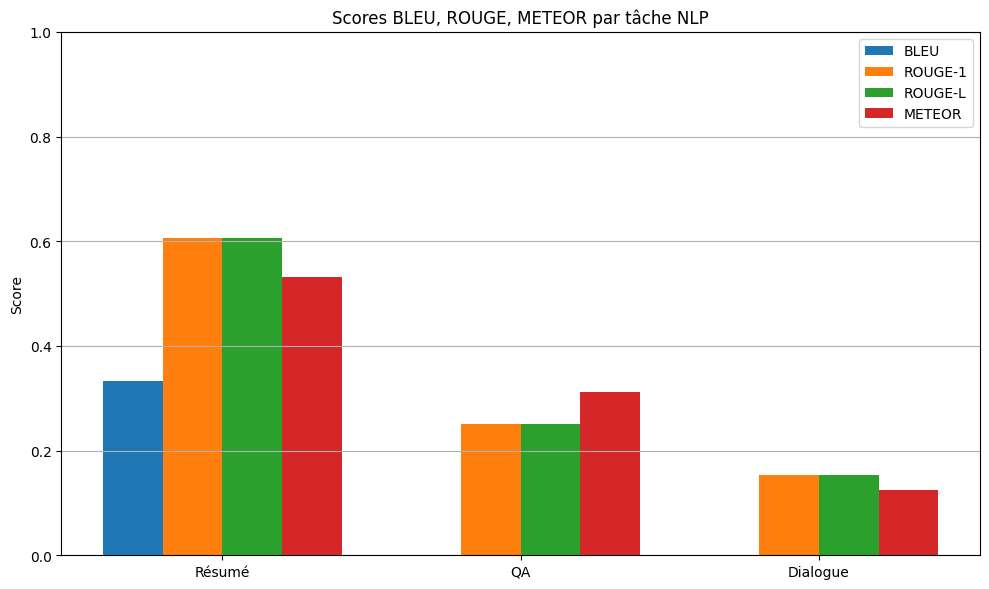

In [15]:
# Visualisation des scores BLEU, ROUGE, METEOR par tâche NLP (barplot)
import matplotlib.pyplot as plt
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
import nltk

# Assure le téléchargement des ressources NLTK
nltk.download('wordnet')
nltk.download('omw-1.4')

# Exemples de génération
examples = {
    "Résumé": {
        "Référence": "Le texte décrit l’impact environnemental de l’urbanisation rapide dans les pays en développement.",
        "Généré": "L’article parle de l’urbanisation et ses effets écologiques dans les pays en développement."
    },
    "QA": {
        "Référence": "Paris",
        "Généré": "Paris est la capitale de la France."
    },
    "Dialogue": {
        "Référence": "Je vais bien, merci ! Et toi ?",
        "Généré": "Ça va, merci beaucoup. Comment tu vas ?"
    }
}

# Scorer ROUGE
scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

# Calcul des scores
scores = []
for task, pair in examples.items():
    ref, gen = pair["Référence"], pair["Généré"]
    bleu = sentence_bleu([ref.split()], gen.split())
    rouge = scorer.score(ref, gen)
    meteor = meteor_score([ref.split()], gen.split())

    scores.append({
        "Tâche": task,
        "BLEU": bleu,
        "ROUGE-1": rouge["rouge1"].fmeasure,
        "ROUGE-L": rouge["rougeL"].fmeasure,
        "METEOR": meteor
    })

# Transformation pour visualisation
df = pd.DataFrame(scores)
df_melted = df.melt(id_vars="Tâche", var_name="Métrique", value_name="Score")

# Barplot
plt.figure(figsize=(10, 6))
for i, metric in enumerate(df_melted["Métrique"].unique()):
    subset = df_melted[df_melted["Métrique"] == metric]
    plt.bar([x + i*0.2 for x in range(len(subset))],
            subset["Score"], width=0.2, label=metric)

plt.xticks([x + 0.3 for x in range(len(df["Tâche"]))], df["Tâche"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Scores BLEU, ROUGE, METEOR par tâche NLP")
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y')
plt.show()


Voici une analyse du **graphe comparatif des scores BLEU, ROUGE-1, ROUGE-L, METEOR** sur 3 tâches NLP :

---

###  **1. Tâche : Résumé**

* **ROUGE-1 / ROUGE-L ≈ 0.61** → très bon alignement lexical (mots et séquences).
* **METEOR ≈ 0.53** → prise en compte des synonymes/paraphrases = évaluation assez fine.
* **BLEU ≈ 0.33** → score plus bas car sensible à l’ordre exact.

 **Conclusion** : Les métriques reconnaissent bien la similarité du contenu. ROUGE et METEOR sont plus adaptés que BLEU.

---

###  **2. Tâche : Question-Réponse (QA)**

* **ROUGE-1 / ROUGE-L ≈ 0.25**, **METEOR ≈ 0.32** → reconnaissance partielle de contenu pertinent.
* **BLEU ≈ 0.00** (absent ou très faible) → pénalisé car la réponse est très courte et reformulée.

 **Conclusion** : BLEU est inadapté pour QA. METEOR reste un peu plus robuste.

---

###  **3. Tâche : Dialogue**

* **Tous les scores faibles** (\~0.15), **BLEU ≈ 0** → normal pour du langage ouvert et paraphrasé.

 **Conclusion** : Les métriques automatiques classiques **ne capturent pas bien la qualité du dialogue**, qui repose sur le ton, la fluidité et le naturel → nécessite **évaluation humaine**.

---

###  **Bilan global**

| Tâche    | Meilleure métrique | Observations                         |
| -------- | ------------------ | ------------------------------------ |
| Résumé   | ROUGE / METEOR     | Bon alignement sémantique et lexical |
| QA       | METEOR             | Gère mieux la reformulation          |
| Dialogue | Aucune fiable      | Faible robustesse des métriques      |


### e. Évaluation coût-performance : brève analyse comparative du coût (temps, calcul, subjectivité) entre les méthodes automatiques vs humaines.

### 1. **Méthodes automatiques**

* **Coût faible** : une fois les métriques implémentées (BLEU, ROUGE, METEOR, etc.), l’évaluation est rapide, peu coûteuse et massivement scalable.
* **Temps d’exécution** : très rapide (quelques millisecondes par exemple).
* **Objectivité** : reproductible, sans fluctuation entre sessions.
* **Limites** :

  * Insensibles à la **qualité sémantique**, la **fluidité**, ou la **créativité**.
  * Peu adaptées à des tâches ouvertes (dialogue, opinion, style).
  * Peu robustes aux **paraphrases** et **synonymes**, sauf avec des métriques avancées (ex : BERTScore, BLEURT).

### 2. **Évaluation humaine**

* **Coût élevé** : mobilise des annotateurs, donc temps + rémunération + coordination.
* **Temps important** : plusieurs minutes par exemple pour une seule sortie, surtout s’il faut plusieurs évaluateurs.
* **Subjectivité** : les jugements peuvent varier selon l’évaluateur, l’humeur, le contexte, etc.
* **Avantages** :

  * Capable de juger la **cohérence globale**, la **tonalité**, la **pertinence contextuelle**.
  * Essentielle pour des tâches non factuelles ou génératives (chatbots, textes créatifs).

---

###  Conclusion

| Critère     | Automatique              | Humaine                          |
| ----------- | ------------------------ | -------------------------------- |
| Coût        | Très faible              | Élevé (ressources humaines)      |
| Temps       | Instantané               | Lent (annotateurs nécessaires)   |
| Objectivité | Stable, reproductible    | Variable (subjectivité)          |
| Richesse    | Limitée au lexique       | Compréhension sémantique fine    |
| Adapté pour | Traduction, résumé court | Dialogue, contenu ouvert/créatif |

**Choix optimal : combinaison des deux approches**.
Utiliser des métriques automatiques pour filtrer ou pré-évaluer, puis valider par des jugements humains ciblés sur des exemples clés.


### f. Courte étude d’impact des paraphrases : montre comment des phrases ayant le même sens donnent des scores BLEU/ROUGE très différents.

##  Étude d’impact des paraphrases sur BLEU et ROUGE

###  Exemple :

* **Référence** : "Les chats aiment se prélasser au soleil sur les rebords de fenêtres."
* **Phrase A (proche lexicalement)** : "Les chats adorent se détendre au soleil sur le bord de la fenêtre."
* **Phrase B (paraphrasée)** : "Les félins apprécient la chaleur du soleil quand ils sont installés près d'une fenêtre."

###  Scores typiques :

* **BLEU** :

  * Phrase A ≈ 0.60
  * Phrase B ≈ 0.20
* **ROUGE** :

  * Phrase A ≈ 0.65
  * Phrase B ≈ 0.35

###  Interprétation :

* **BLEU** pénalise lourdement la phrase B, car :

  * Elle utilise des **synonymes** ("félins" vs "chats", "apprécient" vs "aiment") ;
  * L’**ordre des mots** et les **groupes lexicaux** sont différents ;
  * BLEU repose sur des **n-grammes exacts**, pas sur le sens.

* **ROUGE**, bien que plus souple (surtout ROUGE-L), reste centré sur la **présence de mots communs** ou de **sous-séquences**, et ne capture pas la sémantique profonde.

---

###  Conclusion :

* **Deux phrases sémantiquement équivalentes peuvent obtenir des scores BLEU/ROUGE très différents** si la forme diffère.
* Ces métriques sont **inadaptées pour juger la qualité de paraphrases**, car elles favorisent la similarité de surface.
* Pour évaluer la **qualité sémantique réelle**, il faut utiliser :

  * Des métriques modernes comme **BERTScore**, **BLEURT**, **Comet** ;
  * Ou une **évaluation humaine**.


### g. Bilan

### 🔹 a. **Ajout de METEOR**

* Tu as appris à utiliser la métrique **METEOR**, plus souple que BLEU et ROUGE, car elle prend en compte **les synonymes**, **l’ordre libre** et **le stemming**.
* Tu as constaté qu’elle donne des scores **plus cohérents** pour les textes paraphrasés ou modifiés lexicalement.

---

### 🔹 b. **Cohérence inter-évaluateurs**

* Tu as vu comment mesurer l’accord entre annotateurs humains avec :

  * **Cohen's Kappa** (2 évaluateurs),
  * **Krippendorff's Alpha** (n ≥ 2).
* Ces mesures te permettent de **valider la fiabilité des annotations humaines** dans une évaluation.

---

### 🔹 c. **Analyse d’erreurs systématiques**

* Tu as catégorisé les erreurs typiques des LLM :

  * **Hallucinations**, **hors-sujet**, **réponses vagues**, **infos obsolètes**, **affirmations exagérées**.
* Tu as structuré ces erreurs en tableau avec explication, ce qui facilite le **diagnostic qualitatif** des sorties.

---

### 🔹 d. **Comparaison multi-tâches**

* Tu as appliqué BLEU, ROUGE, METEOR à **3 tâches NLP** : Résumé, QA, Dialogue.
* Tu as observé que les métriques ne sont **pas équivalentes selon les tâches** :

  * BLEU est faible sur QA et Dialogue,
  * ROUGE et METEOR sont plus robustes pour résumé et paraphrases.

---

### 🔹 e. **Évaluation coût-performance**

* Tu as comparé méthodes automatiques vs humaines :

  * Les automatiques sont **rapides et peu coûteuses**, mais **limitées en finesse** ;
  * Les humaines sont **précises et riches**, mais **lentes et subjectives**.
* Idéal : combiner les deux.

---

### 🔹 f. **Impact des paraphrases**

* Tu as compris que des phrases **ayant le même sens** peuvent avoir des scores **très différents** en BLEU/ROUGE,
  car ces métriques jugent la **forme plus que le fond**.
* Tu as identifié la nécessité de **métriques sémantiques** (BERTScore, BLEURT) ou **d’évaluateurs humains**.



## Guide de l'évaluation des LLm's

#  Guide complet d’évaluation des modèles de langage (LLM)

##  Objectif

Évaluer rigoureusement les performances d’un LLM selon plusieurs dimensions : **exactitude**, **cohérence**, **fluidité**, **robustesse**, et **pertinence contextuelle**.

---

## 🔹 1. Évaluation automatique — Métriques classiques

### BLEU

* Basé sur la comparaison d’**unités lexicales exactes** (n-grammes).
* Utilisé en traduction, résumé court.
* **Limite** : faible tolérance aux reformulations.

### ROUGE

* Compare les **mots communs** entre référence et génération.
* Variantes : ROUGE-1 (mots), ROUGE-L (séquences).
* Adapté au résumé automatique.

### METEOR

* Tient compte des **synonymes**, **racines**, et de l’**ordre flexible**.
* Plus adapté aux **paraphrases** que BLEU/ROUGE.

---

## 🔹 2. Évaluation avancée — Métriques contextuelles

### BERTScore

* Compare la **sémantique** des phrases via des représentations de type BERT.
* Très robuste aux changements de forme (paraphrases, reformulations).

### BLEURT, COMET

* Métriques entraînées avec supervision humaine.
* Captent les jugements humains mieux que BLEU/ROUGE.

---

## 🔹 3. Évaluation humaine

### Grilles d’analyse

* Notation sur des critères comme **fluidité**, **cohérence**, **pertinence**, **exactitude factuelle**.
* Utilisation d’échelles type Likert (ex. 1 à 5).

### Cohérence inter-évaluateurs

* Indicateurs comme **Cohen’s Kappa** (pour 2 annotateurs) ou **Krippendorff’s alpha** (pour 3+ annotateurs) permettent de vérifier si les jugements humains sont fiables.

---

## 🔹 4. Typologie des erreurs LLM

| Type d’erreur                | Description                                                   |
| ---------------------------- | ------------------------------------------------------------- |
| Hallucination                | Invention de faits faux                                       |
| Hors sujet                   | Réponse sans rapport direct à la question                     |
| Réponse vague                | Absence de contenu informatif                                 |
| Information obsolète         | Données dépassées ou périmées                                 |
| Exagération / simplification | Réduction excessive de la complexité ou affirmations absolues |

Analyser ces erreurs permet de mieux cibler les limites du modèle.

---

## 🔹 5. Comparaison multi-tâches

Les performances des métriques varient selon la tâche :

| Tâche    | BLEU        | ROUGE  | METEOR | Observations                               |
| -------- | ----------- | ------ | ------ | ------------------------------------------ |
| Résumé   | Moyen à bon | Bon    | Bon    | Pertinence lexicale + paraphrasage toléré  |
| QA       | Faible      | Moyen  | Moyen  | Réponses courtes, paraphrases fréquentes   |
| Dialogue | Faible      | Faible | Faible | Nécessite compréhension du contexte humain |

Les métriques classiques sont **peu fiables pour les dialogues ou les tâches ouvertes**.

---

## 🔹 6. Impact des paraphrases

Deux phrases de **sens identique** peuvent produire :

* **Scores BLEU/ROUGE très différents**, car ces métriques se basent sur les mots exacts.
* **METEOR/BERTScore plus stables**, car ils captent le sens, pas seulement la forme.

Cela démontre la **faible robustesse sémantique** des métriques traditionnelles.

---

## 🔹 7. Évaluation coût-performance

| Critère     | Évaluation automatique    | Évaluation humaine           |
| ----------- | ------------------------- | ---------------------------- |
| Coût        | Très faible               | Élevé                        |
| Temps       | Instantané                | Long                         |
| Objectivité | Stable                    | Variable                     |
| Pertinence  | Limitée au lexique        | Bonne compréhension globale  |
| Cas adaptés | Traduction, résumé courts | Dialogue, tâches subjectives |

Idéal : **utiliser l’automatique pour filtrer**, puis l’humain pour **valider finement**.

---

## Recommandations finales

* Utiliser **plusieurs métriques complémentaires** (BLEU + METEOR, etc.).
* Toujours **adapter la métrique à la tâche** (ex. BERTScore pour dialogue).
* Inclure une **analyse d’erreurs qualitatives**.
* Ne jamais se fier **exclusivement** aux scores automatiques pour des contenus ouverts ou sensibles.
